# Факт vs Прогноз по пекарням

Оценка качества модели на уровне пекарни и SKU.

Для выбранной пекарни строится **10 графиков**:
- график 1 — суммарные продажи пекарни за день (факт vs прогноз);
- графики 2..10 — топ-9 SKU этой пекарни по объёму продаж (факт vs прогноз).

Ось X — день, ось Y — количество.

Источник данных — holdout-бэктест за май 2026 (`prod_holdout_sku_backtest`).
Можно переключать вариант модели через `MODEL_VARIANT` ниже.

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# ----------------------------------------------------------------------
# Корень проекта (ноутбук лежит в notebooks/)
# ----------------------------------------------------------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.exists(os.path.join(PROJECT_ROOT, "reports")):
    PROJECT_ROOT = os.getcwd()  # если запущено из корня
print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = c:\Users\dns\Desktop\Projects\demand-forecasting-model


## Настройки

`MODEL_VARIANT` — какой вариант модели смотреть.
- `"baseline"` — базовый holdout (`prod_holdout_sku_compare.csv`);
- любое имя варианта из `prod_holdout_sku_backtest_variants/` без суффикса `_compare`,
  например `"runner_city_prior_soft_weekpart"` (текущий прод-режим).

In [19]:
# === ГЛАВНЫЕ НАСТРОЙКИ ===

# Вариант модели. "baseline" или имя из variants (см. список ниже).
MODEL_VARIANT = "runner_city_prior_soft_weekpart"

# Сколько SKU-графиков (всего графиков = N_SKU + 1 уровень пекарни).
N_SKU = 9

BASELINE_PATH = os.path.join(
    PROJECT_ROOT, "reports", "prod_holdout_sku_backtest", "prod_holdout_sku_compare.csv"
)
VARIANTS_DIR = os.path.join(
    PROJECT_ROOT, "reports", "prod_holdout_sku_backtest_variants"
)


def variant_path(variant: str) -> str:
    if variant == "baseline":
        return BASELINE_PATH
    return os.path.join(VARIANTS_DIR, f"{variant}_compare.csv")


# Доступные варианты
available = ["baseline"]
if os.path.isdir(VARIANTS_DIR):
    available += sorted(
        f[: -len("_compare.csv")]
        for f in os.listdir(VARIANTS_DIR)
        if f.endswith("_compare.csv")
    )
print("Доступные варианты модели:")
for v in available:
    mark = "  <-- выбран" if v == MODEL_VARIANT else ""
    print(f"  {v}{mark}")

assert os.path.exists(variant_path(MODEL_VARIANT)), (
    f"Не найден файл варианта: {variant_path(MODEL_VARIANT)}"
)

Доступные варианты модели:
  baseline
  adaptive_recent
  anti_cannibalization_cap
  baseline
  blend_recent_50
  category_preserving
  core_recent_70
  runner_city_prior_soft
  runner_city_prior_soft_weekpart  <-- выбран
  runner_city_prior_strong
  runner_city_prior_strong_weekpart
  runner_floor_90
  runner_recent_heavy
  runner_recent_heavy_dow_shrink
  runner_recent_heavy_robust_weekpart
  runner_recent_heavy_weekpart
  runner_residual_redistribution
  topn_runner_protection


## Загрузка данных

Файлы крупные (~240 МБ), поэтому грузим только нужные колонки.
Колонка прогноза называется `forecast_qty` в baseline и `forecast_variant` в вариантах — нормализуем к `forecast_qty`.

In [20]:
_CACHE = {}


def load_variant(variant: str) -> pd.DataFrame:
    """Грузит дневной факт/прогноз по SKU для выбранного варианта модели."""
    if variant in _CACHE:
        return _CACHE[variant]

    path = variant_path(variant)
    # Определяем имя колонки прогноза
    head = pd.read_csv(path, nrows=0)
    fcol = "forecast_qty" if "forecast_qty" in head.columns else "forecast_variant"

    usecols = [
        "date", "bakery_id", "bakery_name", "city",
        "product_id", "product_name", "category_name",
        "fact_qty", fcol,
    ]
    df = pd.read_csv(path, usecols=usecols)
    df = df.rename(columns={fcol: "forecast_qty"})
    df["date"] = pd.to_datetime(df["date"])
    _CACHE[variant] = df
    print(
        f"Загружен '{variant}': строк={len(df):,}, "
        f"даты {df['date'].min().date()}..{df['date'].max().date()}, "
        f"пекарен={df['bakery_id'].nunique()}"
    )
    return df


df = load_variant(MODEL_VARIANT)
df.head()

Загружен 'runner_city_prior_soft_weekpart': строк=909,648, даты 2026-05-02..2026-05-31, пекарен=187


,date,bakery_id,bakery_name,city,product_id,product_name,category_name,fact_qty,forecast_qty
0,2026-05-02,1,Столичная 37А Зеленодольск,Зеленодольск,5,Зерновой,Хлеб,2.0,3.221174
1,2026-05-03,1,Столичная 37А Зеленодольск,Зеленодольск,5,Зерновой,Хлеб,2.0,3.400327
2,2026-05-04,1,Столичная 37А Зеленодольск,Зеленодольск,5,Зерновой,Хлеб,4.0,4.221669
3,2026-05-05,1,Столичная 37А Зеленодольск,Зеленодольск,5,Зерновой,Хлеб,2.0,3.336616
4,2026-05-06,1,Столичная 37А Зеленодольск,Зеленодольск,5,Зерновой,Хлеб,2.0,4.024552


## Список пекарен

Таблица для удобного выбора: id, название, город, средние продажи в день и WMAPE на уровне пекарни.
Чем ниже WMAPE — тем точнее модель по этой пекарне.

In [21]:
def bakery_overview(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby(["bakery_id", "bakery_name", "city"], as_index=False).agg(
        fact_qty=("fact_qty", "sum"),
        forecast_qty=("forecast_qty", "sum"),
    )
    n_days = df["date"].nunique()
    # WMAPE на уровне пекарни (по дневным суммам)
    day = df.groupby(["bakery_id", "date"], as_index=False).agg(
        f=("fact_qty", "sum"), p=("forecast_qty", "sum")
    )
    day["abs_err"] = (day["f"] - day["p"]).abs()
    wm = day.groupby("bakery_id").apply(
        lambda x: 100 * x["abs_err"].sum() / max(x["f"].sum(), 1e-9),
        include_groups=False,
    ).rename("wmape_pct")
    g = g.merge(wm, on="bakery_id")
    g["fact_per_day"] = (g["fact_qty"] / n_days).round(0)
    g["bias_pct"] = (100 * (g["forecast_qty"] - g["fact_qty"]) / g["fact_qty"].clip(lower=1e-9)).round(1)
    g["wmape_pct"] = g["wmape_pct"].round(1)
    return g[["bakery_id", "bakery_name", "city", "fact_per_day", "wmape_pct", "bias_pct"]].sort_values("wmape_pct")


overview = bakery_overview(df)
print(f"Всего пекарен: {len(overview)}")
print("\nЛучшие 15 (низкий WMAPE):")
display(overview.head(15))
print("Худшие 15 (высокий WMAPE):")
display(overview.tail(15))

Всего пекарен: 187

Лучшие 15 (низкий WMAPE):


,bakery_id,bakery_name,city,fact_per_day,wmape_pct,bias_pct
51,60,Мусина 68 Казань,Казань,1367.0,5.3,-0.0
87,108,Чулман 9 Нижнекамск,Нижнекамск,1216.0,5.8,-2.7
42,47,Вагапова 3 Казань,Казань,1285.0,7.1,-5.1
68,82,Карбышева 40 Казань,Казань,1057.0,7.2,-2.8
173,258,Аббасова 4 Казань,Казань,548.0,7.3,2.2
120,165,Декабристов 85 Казань,Казань,868.0,8.1,0.1
130,176,Радужная 7 Чебоксары,Чебоксары,1004.0,8.2,-4.9
142,190,Мира 7 Казань,Казань,554.0,8.2,0.9
106,146,Фучика 105А Казань,Казань,673.0,8.3,-1.2
125,171,Б. Хмельницкого 109/3 Чебоксары,Чебоксары,864.0,8.4,-3.9


Худшие 15 (высокий WMAPE):


,bakery_id,bakery_name,city,fact_per_day,wmape_pct,bias_pct
140,187,2-я юго-западная 30 Казань,Казань,712.0,26.9,26.0
185,272,Четаева 4 Казань,Казань,201.0,27.4,-12.5
110,152,Менделеева 35А Нижнекамск,Нижнекамск,649.0,27.6,27.4
162,243,Дейнеки 1 Курск,Курск,439.0,27.8,27.8
186,273,Проспект Универсиады 10 Казань,Казань,112.0,28.7,-17.8
139,186,Адоратского 38Д Казань,Казань,281.0,29.0,26.1
183,268,Новогородская 40 Чебоксары,Чебоксары,209.0,29.3,17.5
144,200,Университетская 4 Казань,Казань,586.0,30.0,29.0
94,116,Горького 51 Чебоксары,Чебоксары,543.0,31.4,30.3
163,244,Магистральный проезд 18 Курск,Курск,355.0,31.7,31.7


In [22]:
# Поиск пекарни по части названия (помощь в выборе id)
def find_bakery(query: str) -> pd.DataFrame:
    q = query.lower()
    mask = overview["bakery_name"].str.lower().str.contains(q) | overview["city"].str.lower().str.contains(q)
    return overview[mask]


find_bakery("казань").head(20)

,bakery_id,bakery_name,city,fact_per_day,wmape_pct,bias_pct
51,60,Мусина 68 Казань,Казань,1367.0,5.3,-0.0
42,47,Вагапова 3 Казань,Казань,1285.0,7.1,-5.1
68,82,Карбышева 40 Казань,Казань,1057.0,7.2,-2.8
173,258,Аббасова 4 Казань,Казань,548.0,7.3,2.2
120,165,Декабристов 85 Казань,Казань,868.0,8.1,0.1
142,190,Мира 7 Казань,Казань,554.0,8.2,0.9
106,146,Фучика 105А Казань,Казань,673.0,8.3,-1.2
111,153,Рауиса Гареева 96 Казань,Казань,1018.0,8.6,-5.5
84,105,Фучика 96 Казань,Казань,1658.0,8.9,-5.7
38,42,Белинского 9/6 Казань,Казань,1009.0,9.4,-4.8


## Построение графиков

`plot_bakery(bakery)` — `bakery` может быть `bakery_id` (int) или частью названия (str).
Строит сетку 10 графиков: уровень пекарни + топ-9 SKU по факту.

In [23]:
def _resolve_bakery_id(df: pd.DataFrame, bakery) -> int:
    if isinstance(bakery, (int, np.integer)):
        return int(bakery)
    # строка -> поиск по названию
    cand = df[df["bakery_name"].str.lower().str.contains(str(bakery).lower())]
    ids = cand["bakery_id"].unique()
    if len(ids) == 0:
        raise ValueError(f"Пекарня не найдена по запросу: {bakery!r}")
    if len(ids) > 1:
        names = cand[["bakery_id", "bakery_name"]].drop_duplicates()
        raise ValueError(
            f"Найдено несколько пекарен по {bakery!r}, уточните id:\n{names.to_string(index=False)}"
        )
    return int(ids[0])


def plot_bakery(bakery, df: pd.DataFrame = None, n_sku: int = None, savepath: str = None):
    if df is None:
        df = load_variant(MODEL_VARIANT)
    if n_sku is None:
        n_sku = N_SKU

    bid = _resolve_bakery_id(df, bakery)
    sub = df[df["bakery_id"] == bid].copy()
    if sub.empty:
        raise ValueError(f"Нет данных для bakery_id={bid}")

    bname = sub["bakery_name"].iloc[0]
    city = sub["city"].iloc[0]

    # --- топ-N SKU по факту ---
    sku_rank = (
        sub.groupby(["product_id", "product_name"])["fact_qty"].sum()
        .sort_values(ascending=False)
    )
    top_sku = sku_rank.head(n_sku).index.tolist()

    # --- сетка ---
    n_plots = n_sku + 1
    ncols = 2
    nrows = int(np.ceil(n_plots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    def _plot_series(ax, data, title):
        d = data.groupby("date", as_index=False).agg(
            fact=("fact_qty", "sum"), forecast=("forecast_qty", "sum")
        ).sort_values("date")
        ax.plot(d["date"], d["fact"], marker="o", ms=3, lw=1.5, label="факт", color="#1f77b4")
        ax.plot(d["date"], d["forecast"], marker="s", ms=3, lw=1.5, label="прогноз", color="#d62728", alpha=0.85)
        f_sum, p_sum = d["fact"].sum(), d["forecast"].sum()
        wmape = 100 * (d["fact"] - d["forecast"]).abs().sum() / max(f_sum, 1e-9)
        bias = 100 * (p_sum - f_sum) / max(f_sum, 1e-9)
        ax.set_title(f"{title}\nWMAPE={wmape:.0f}%  bias={bias:+.0f}%  факт={f_sum:.0f}", fontsize=9)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
        ax.tick_params(axis="x", labelsize=7, rotation=45)
        ax.tick_params(axis="y", labelsize=7)

    # график 1 — уровень пекарни
    _plot_series(axes[0], sub, f"ПЕКАРНЯ #{bid} — {bname} ({city})")

    # графики 2..N — SKU
    for i, (pid, pname) in enumerate(top_sku, start=1):
        sku_data = sub[sub["product_id"] == pid]
        fact_tot = sku_rank.loc[(pid, pname)]
        _plot_series(axes[i], sku_data, f"#{i} {pname}  (всего факт={fact_tot:.0f})")

    # пустые оси
    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"Факт vs Прогноз — пекарня #{bid} {bname} | модель: {MODEL_VARIANT}",
        fontsize=12, y=1.002,
    )
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=110, bbox_inches="tight")
        print("Сохранено:", savepath)
    plt.show()

## Свежие даты из ClickHouse (опционально)

Holdout-данные выше зафиксированы на **мае 2026**. Чтобы посмотреть **актуальные даты** (июнь и далее), подтяните факт + прогноз напрямую из прод-ClickHouse и постройте те же 10 графиков.

- **Факт** — `Svezhar.fct_check_lines` (только событие «Продажа», с дедупом как в прод-пайплайне).
- **Прогноз** — `sku_forecast_day_snapshots` с `lead_days = 1` (прогноз, сделанный накануне дня — честная оценка).

Снапшоты прогноза копятся только **с даты внедрения (~2026-06-11)**.

Нужны креды ClickHouse в локальном `.env`: `CLICKHOUSE_HOST/PORT/USER/PASSWORD/DATABASE` (или короткие `HOST/PORT/USER/PASSWORD/DATABASE`).

In [24]:
# Установка драйвера при необходимости
try:
    import clickhouse_connect  # noqa: F401
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "clickhouse-connect"])
    import clickhouse_connect  # noqa: F401
print("clickhouse_connect:", clickhouse_connect.__version__)

clickhouse_connect: <module 'clickhouse_connect.__version__' from 'c:\\Users\\dns\\Desktop\\Projects\\demand-forecasting-model\\.venv\\Lib\\site-packages\\clickhouse_connect\\__version__.py'>


In [25]:
import clickhouse_connect


def _read_env(path=None):
    path = path or os.path.join(PROJECT_ROOT, ".env")
    env = {}
    if os.path.exists(path):
        for line in open(path, encoding="utf-8"):
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            k, v = line.split("=", 1)
            env[k.strip()] = v.strip().strip('"').strip("'")
    return env


def get_ch_client():
    """ClickHouse-клиент из .env (поддержка CLICKHOUSE_* и коротких имён)."""
    e = _read_env()
    g = lambda *keys: next((e[k] for k in keys if e.get(k)), None)
    host = g("CLICKHOUSE_HOST", "HOST")
    port = g("CLICKHOUSE_PORT", "PORT")
    user = g("CLICKHOUSE_USER", "USER")
    password = g("CLICKHOUSE_PASSWORD", "PASSWORD")
    database = g("CLICKHOUSE_DATABASE", "DATABASE")
    secure = (g("CLICKHOUSE_SECURE", "SECURE") or "").lower() in ("1", "true", "yes")
    missing = [n for n, v in [("HOST", host), ("PORT", port), ("USER", user),
                              ("PASSWORD", password), ("DATABASE", database)] if not v]
    if missing:
        raise RuntimeError(f"Не заполнены в .env: {', '.join(missing)}")
    return clickhouse_connect.get_client(
        host=host, port=int(port), username=user, password=password,
        database=database, secure=secure,
    )


# Событие "Продажа" в hex (как в прод-шаблонах)
SALE_EVENT_HEX = "D09FD180D0BED0B4D0B0D0B6D0B0"

In [26]:
# === ОКНО ДЛЯ СВЕЖИХ ДАТ (ClickHouse) ===
# Здесь задаются ПЕКАРНИ и ДИАПАЗОН ДАТ для live-режима.

LIVE_BAKERY_IDS = [16, 28, 23]      # какие пекарни тянуть
LIVE_DATE_FROM = "2026-06-11"        # начало окна (>= даты внедрения снапшотов)
LIVE_DATE_TO = "2026-06-24"          # конец окна
LIVE_LEAD_DAYS = 1                   # 1 = прогноз, сделанный накануне дня

print("Окно:", LIVE_DATE_FROM, "..", LIVE_DATE_TO, "| пекарни:", LIVE_BAKERY_IDS)

Окно: 2026-06-11 .. 2026-06-24 | пекарни: [16, 28, 23]


In [27]:
def load_live(bakery_ids, date_from, date_to, lead_days=1):
    """Тянет факт + прогноз (снапшот lead_days) из ClickHouse для списка пекарен.

    Возвращает df в той же схеме, что и holdout: date, bakery_id, bakery_name,
    city, product_id, product_name, category_name, fact_qty, forecast_qty.
    Можно передать в plot_bakery(bid, df=live).
    """
    if isinstance(bakery_ids, (int, np.integer)):
        bakery_ids = [int(bakery_ids)]
    ids_csv = ",".join(str(int(b)) for b in bakery_ids)
    client = get_ch_client()

    # --- ФАКТ: дедуп строк чеков как в прод-агрегате, сумма по дню/пекарне/SKU ---
    fact_sql = f"""
    SELECT
        sales.check_date            AS date,
        sales.bakery_id             AS bakery_id,
        sales.product_id            AS product_id,
        any(db.bakery_name)         AS bakery_name,
        any(db.city)                AS city,
        any(dp.product_name)        AS product_name,
        any(dp.category_name)       AS category_name,
        sum(toFloat64(sales.quantity)) AS fact_qty
    FROM (
        SELECT DISTINCT
            fcl.check_datetime, fcl.check_date, fcl.bakery_id, fcl.product_id,
            fcl.quantity, fcl.price, fcl.line_amount, fcl.cash_event_type
        FROM Svezhar.fct_check_lines AS fcl
        WHERE hex(fcl.cash_event_type) = '{SALE_EVENT_HEX}'
          AND fcl.check_date BETWEEN toDate('{date_from}') AND toDate('{date_to}')
          AND fcl.bakery_id IN ({ids_csv})
    ) AS sales
    ANY LEFT JOIN Svezhar.dim_bakeries AS db ON db.bakery_id = sales.bakery_id
    ANY LEFT JOIN Svezhar.dim_products AS dp ON dp.product_id = sales.product_id
    GROUP BY date, bakery_id, product_id
    """
    fact = client.query_df(fact_sql)

    # --- ПРОГНОЗ: снапшот lead_days, последняя версия по generated_at ---
    fc_sql = f"""
    SELECT
        forecast_date                       AS date,
        bakery_id,
        product_id,
        any(product_name)                   AS product_name,
        any(category_name)                  AS category_name,
        argMax(forecast_qty, generated_at)  AS forecast_qty
    FROM sku_forecast_day_snapshots
    WHERE lead_days = {int(lead_days)}
      AND forecast_date BETWEEN toDate('{date_from}') AND toDate('{date_to}')
      AND bakery_id IN ({ids_csv})
    GROUP BY date, bakery_id, product_id
    """
    fc = client.query_df(fc_sql)
    client.close()

    print(f"  факт: {len(fact):,} строк | прогноз(снапшот lead={lead_days}): {len(fc):,} строк")
    if fact.empty and fc.empty:
        raise ValueError(
            "ClickHouse вернул пусто с ОБЕИХ сторон. Проверьте даты/пекарни/снапшоты "
            "(снапшоты есть только примерно с 2026-06-11)."
        )

    # Гарантируем нужные колонки даже у пустых выборок (иначе merge падает на 'date')
    fact_cols = ["date", "bakery_id", "product_id", "bakery_name", "city",
                 "product_name", "category_name", "fact_qty"]
    fc_cols = ["date", "bakery_id", "product_id", "product_name",
               "category_name", "forecast_qty"]
    if fact.empty:
        fact = pd.DataFrame(columns=fact_cols)
        print("  ВНИМАНИЕ: факт пуст — графики покажут только прогноз.")
    if fc.empty:
        fc = pd.DataFrame(columns=fc_cols)
        print("  ВНИМАНИЕ: прогноз пуст — нет снапшотов lead_days="
              f"{lead_days} за это окно. Попробуйте другой диапазон/lead.")

    # outer merge: видим и dead-pair (прогноз без факта), и пропущенный прогноз
    merged = fact.merge(
        fc, on=["date", "bakery_id", "product_id"], how="outer", suffixes=("", "_fc")
    )
    merged["date"] = pd.to_datetime(merged["date"])
    merged["fact_qty"] = pd.to_numeric(merged.get("fact_qty"), errors="coerce").fillna(0.0)
    merged["forecast_qty"] = pd.to_numeric(merged.get("forecast_qty"), errors="coerce").fillna(0.0)
    merged["product_name"] = merged["product_name"].fillna(merged.get("product_name_fc"))
    merged["category_name"] = merged["category_name"].fillna(merged.get("category_name_fc"))
    for col in ["bakery_name", "city"]:
        if col in merged.columns:
            name_map = merged.dropna(subset=[col]).groupby("bakery_id")[col].first()
            merged[col] = merged["bakery_id"].map(name_map).fillna(merged[col])
        else:
            merged[col] = ""
    merged["product_name"] = merged["product_name"].fillna(merged["product_id"].astype(str))
    merged["category_name"] = merged["category_name"].fillna("")
    cols = ["date", "bakery_id", "bakery_name", "city",
            "product_id", "product_name", "category_name", "fact_qty", "forecast_qty"]
    out = merged[cols].sort_values(["bakery_id", "date", "product_id"]).reset_index(drop=True)
    print(
        f"Live: строк={len(out):,}, даты {out['date'].min().date()}..{out['date'].max().date()}, "
        f"пекарен={out['bakery_id'].nunique()}"
    )
    return out

In [28]:
# Загрузить свежие данные по настройкам выше и построить графики.
# Заполните .env кредами ClickHouse перед запуском.
live = load_live(LIVE_BAKERY_IDS, LIVE_DATE_FROM, LIVE_DATE_TO, lead_days=LIVE_LEAD_DAYS)

for bid in LIVE_BAKERY_IDS:
    plot_bakery(bid, df=live)

KeyError: 'date'

## Использование (holdout, май)

Задайте пекарню по `bakery_id` или по части названия.
Для свежих июньских дат используйте секцию ClickHouse выше.


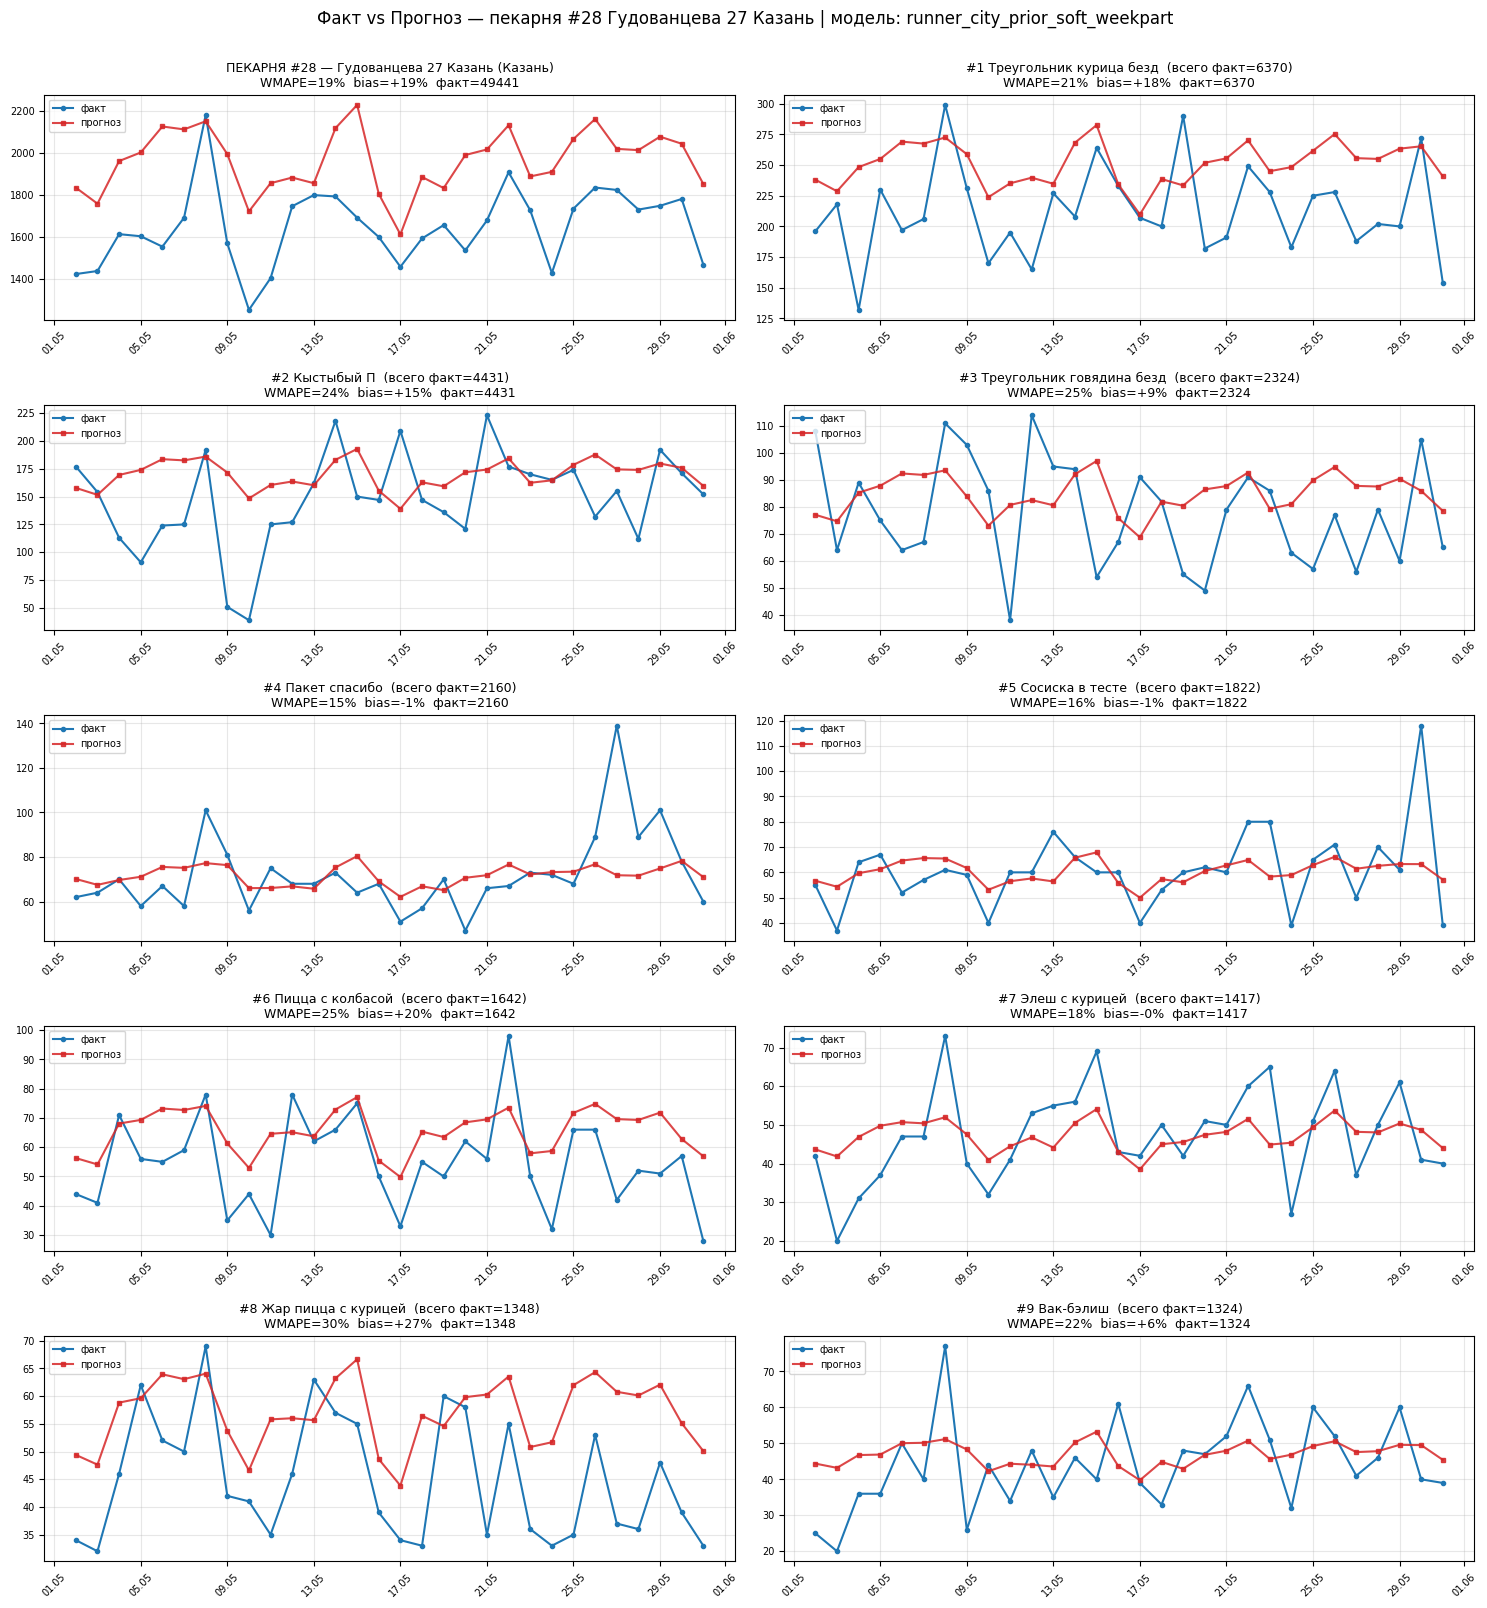

In [29]:
# По id:
plot_bakery(28)

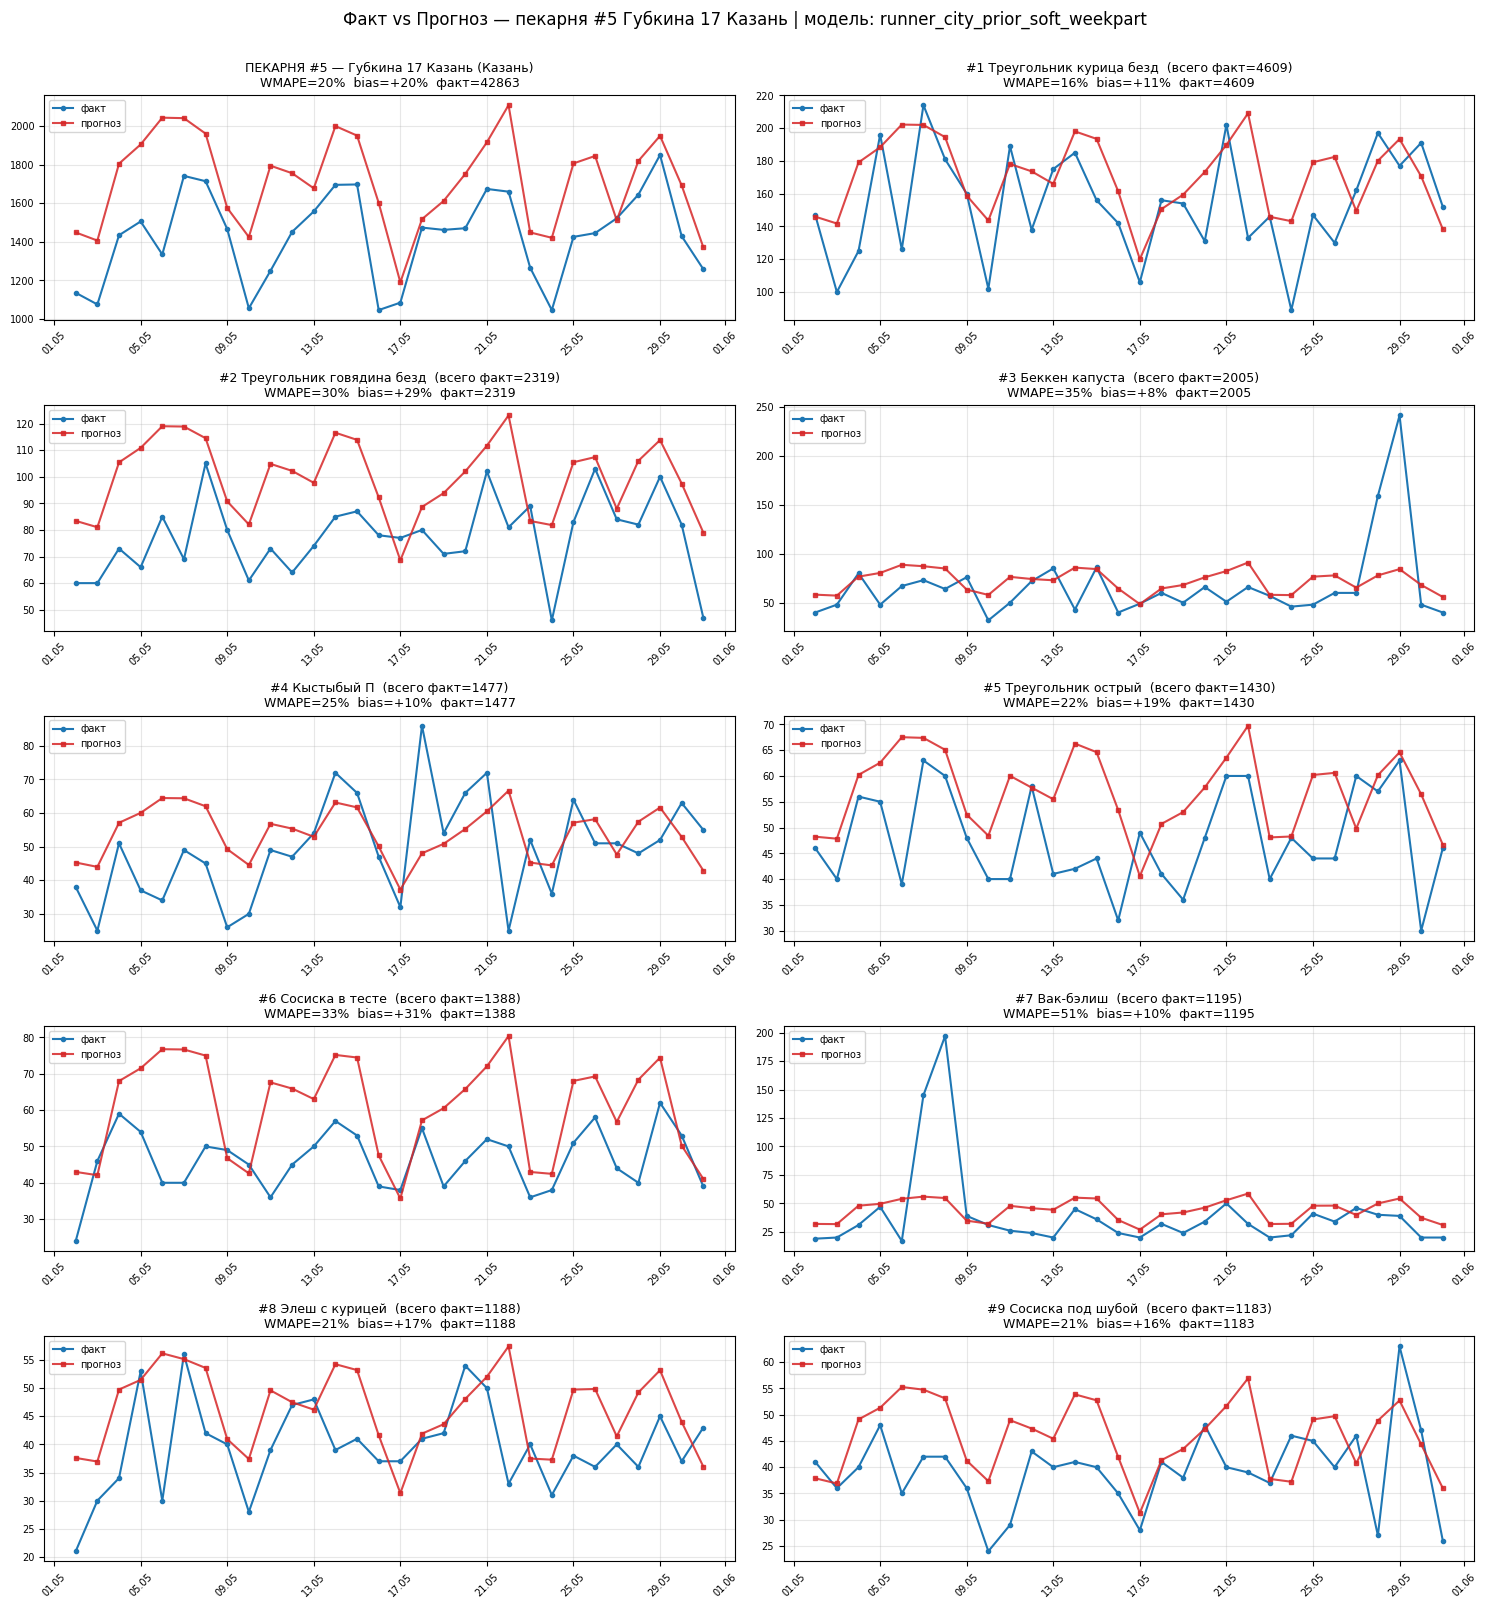

In [30]:
# По названию (если уникально):
plot_bakery("Губкина 17 Казань")

In [ ]:
# Несколько пекарен подряд:
for bid in [16, 28, 14, 89, 23]:
    plot_bakery(bid)

In [ ]:
# Сравнить два варианта модели для одной пекарни:
# plot_bakery(28, df=load_variant("baseline"))
# plot_bakery(28, df=load_variant("runner_city_prior_soft_weekpart"))